In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load CSV
df = pd.read_csv(
    "/Users/joshpelayo/DATA 5322 02 Statistical Machine Learning 2/Final Project/GamingStudy_data.csv",
    encoding="cp1252")
    
print(df.shape)
df.head()

(13464, 55)


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,...,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,...,USA,USA,Reddit,Singleplayer,Accept,1,23,5.0,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,...,USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33.0,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,...,Germany,Germany,Reddit,Singleplayer,Accept,8,17,31.0,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,...,USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11.0,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,...,USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13.0,KOR,USA


In [2]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nSummary Statistics:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13464 entries, 0 to 13463
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S. No.           13464 non-null  int64  
 1   Timestamp        13464 non-null  float64
 2   GAD1             13464 non-null  int64  
 3   GAD2             13464 non-null  int64  
 4   GAD3             13464 non-null  int64  
 5   GAD4             13464 non-null  int64  
 6   GAD5             13464 non-null  int64  
 7   GAD6             13464 non-null  int64  
 8   GAD7             13464 non-null  int64  
 9   GADE             12815 non-null  object 
 10  SWL1             13464 non-null  int64  
 11  SWL2             13464 non-null  int64  
 12  SWL3             13464 non-null  int64  
 13  SWL4             13464 non-null  int64  
 14  SWL5             13464 non-null  int64  
 15  Game             13464 non-null  object 
 16  Platform         13464 non-null  object 
 17  Hours       

,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SWL1,...,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SWL_T,SPIN_T
count,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,...,13277.000000,13308.000000,13317.000000,13317.000000,13289.000000,13441.000000,13464.000000,13464.000000,13464.000000,12814.000000
mean,7096.839201,42054.841222,0.860963,0.673351,0.965761,0.724079,0.488042,0.911022,0.588755,3.720440,...,0.538827,1.252405,1.411054,0.620635,0.935962,2.027677,20.930407,5.211973,19.788844,19.848525
std,4114.478220,0.272948,0.926542,0.915724,0.982776,0.921971,0.837014,0.931168,0.894408,1.736264,...,0.944180,1.207463,1.349874,0.961853,1.180456,1.061842,3.300897,4.713267,7.229243,13.467493
min,1.000000,42052.004370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,5.000000,0.000000
25%,3532.750000,42054.716548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,2.000000,14.000000,9.000000
50%,7087.500000,42054.800675,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,4.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,20.000000,4.000000,20.000000,17.000000
75%,10654.250000,42054.932112,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,5.000000,...,1.000000,2.000000,2.000000,1.000000,2.000000,3.000000,22.000000,8.000000,26.000000,28.000000
max,14250.000000,42058.363750,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,7.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,63.000000,21.000000,35.000000,68.000000


In [3]:
# Only remove identifiers
eda_df = df.drop(
    columns=["S. No.", "Timestamp"],
    errors="ignore"
)

print(eda_df.shape)
eda_df.head()

display(eda_df.describe(include="all"))

missing = (
    eda_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing[missing > 0])

(13464, 53)


,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,...,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
count,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,13464.000000,12815,13464.000000,13464.000000,...,13464,13464,13449,13464,13050,13464.000000,13464.000000,12814.000000,13354,13343
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,...,126,109,4,298,1,NaN,NaN,NaN,107,124
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not difficult at all,NaN,NaN,...,USA,USA,Reddit,Multiplayer - online - with real life friends,Accept,NaN,NaN,NaN,USA,USA
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6236,NaN,NaN,...,4261,4569,13324,5564,13050,NaN,NaN,NaN,4569,4261
mean,0.860963,0.673351,0.965761,0.724079,0.488042,0.911022,0.588755,NaN,3.720440,4.602050,...,NaN,NaN,NaN,NaN,NaN,5.211973,19.788844,19.848525,NaN,NaN
std,0.926542,0.915724,0.982776,0.921971,0.837014,0.931168,0.894408,NaN,1.736264,1.696276,...,NaN,NaN,NaN,NaN,NaN,4.713267,7.229243,13.467493,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000,0.000000,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,3.000000,...,NaN,NaN,NaN,NaN,NaN,2.000000,14.000000,9.000000,NaN,NaN
50%,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,NaN,4.000000,5.000000,...,NaN,NaN,NaN,NaN,NaN,4.000000,20.000000,17.000000,NaN,NaN
75%,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,NaN,5.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,8.000000,26.000000,28.000000,NaN,NaN


highestleague      13464
League              1852
Degree              1577
SPIN_T               650
GADE                 649
accept               414
SPIN13               187
SPIN11               187
SPIN17               175
SPIN12               168
SPIN5                166
SPIN10               160
SPIN4                159
SPIN9                158
SPIN6                156
SPIN14               156
SPIN2                154
SPIN15               147
SPIN16               147
SPIN8                144
SPIN3                140
SPIN7                138
SPIN1                124
Birthplace_ISO3      121
Residence_ISO3       110
streams              100
Work                  38
Hours                 30
Narcissism            23
Reference             15
dtype: int64


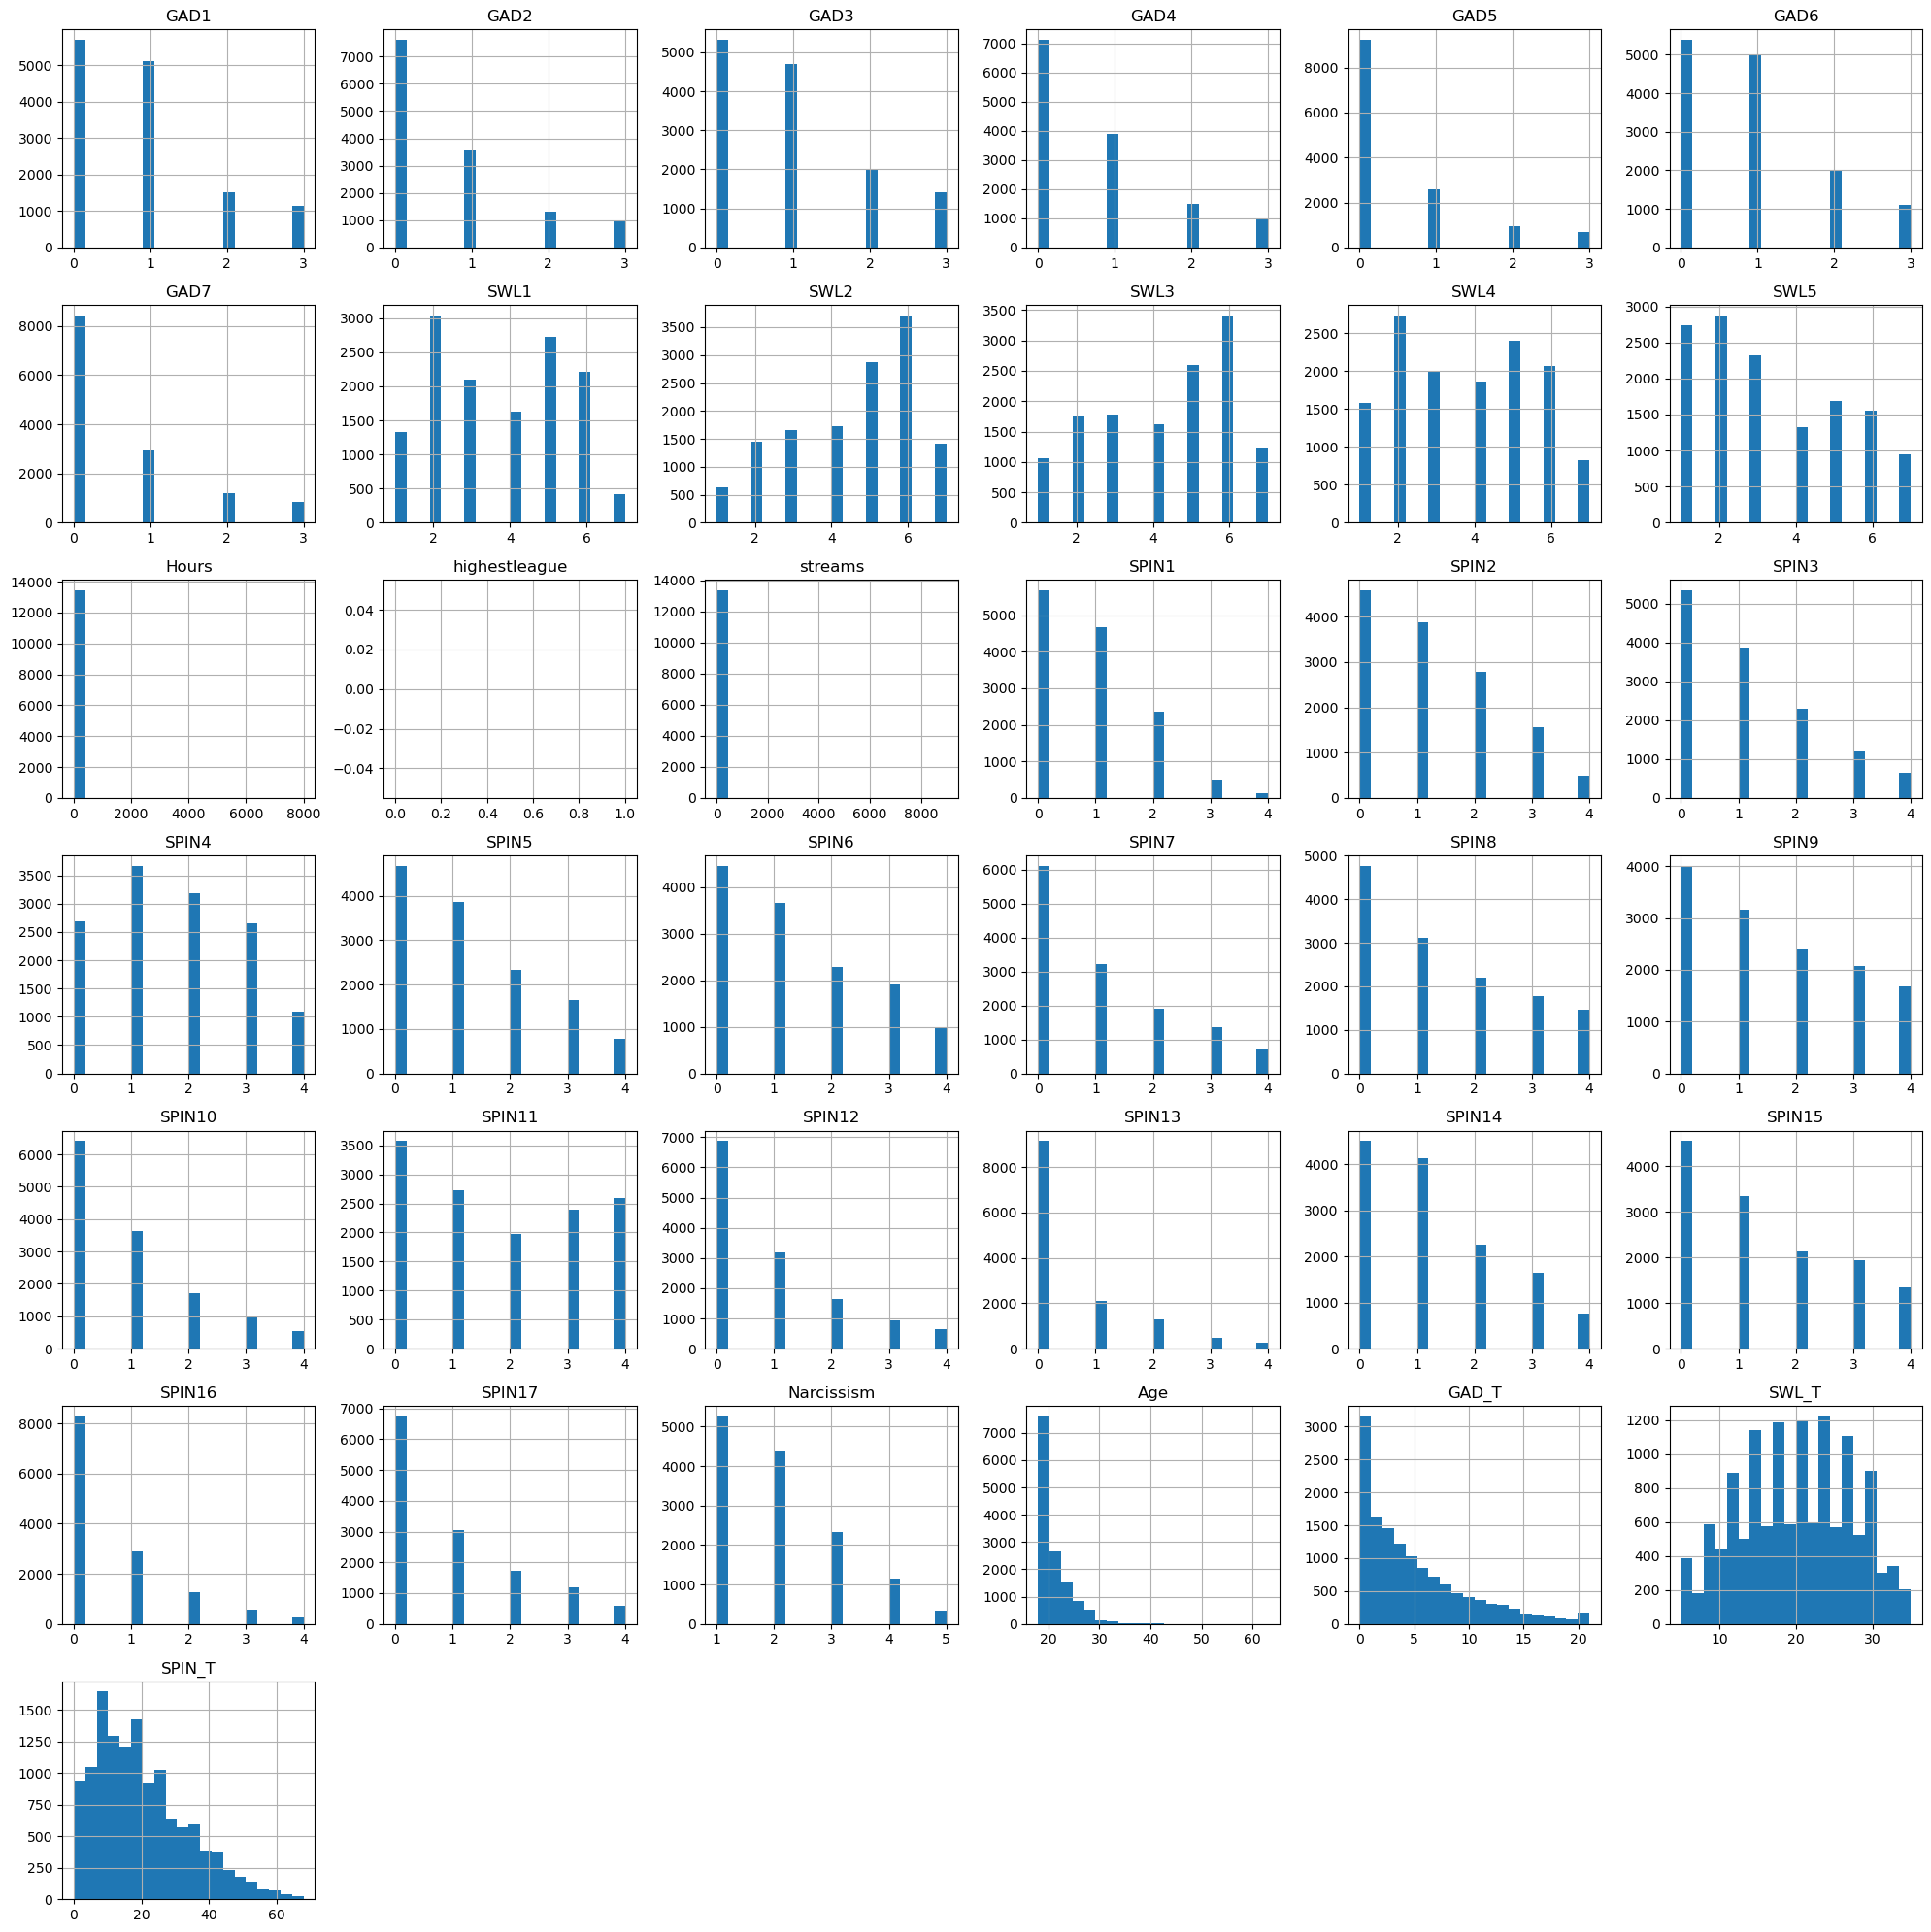

In [4]:
numeric_cols = eda_df.select_dtypes(include=np.number).columns

eda_df[numeric_cols].hist(
    figsize=(20, 20),
    bins=20
)

plt.tight_layout()
plt.show()

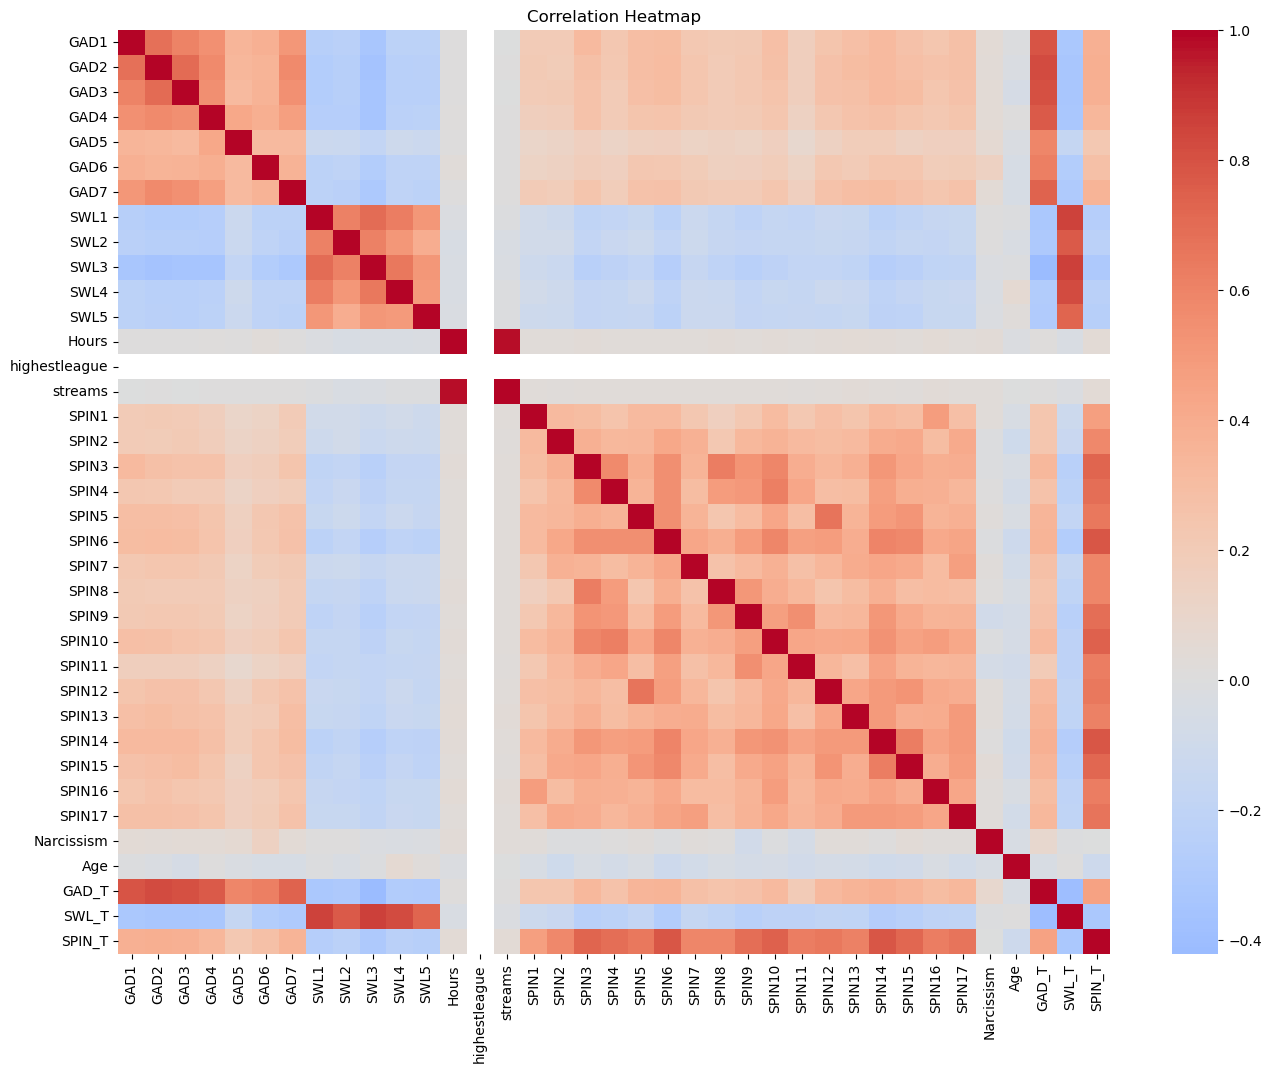

In [5]:
corr = eda_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

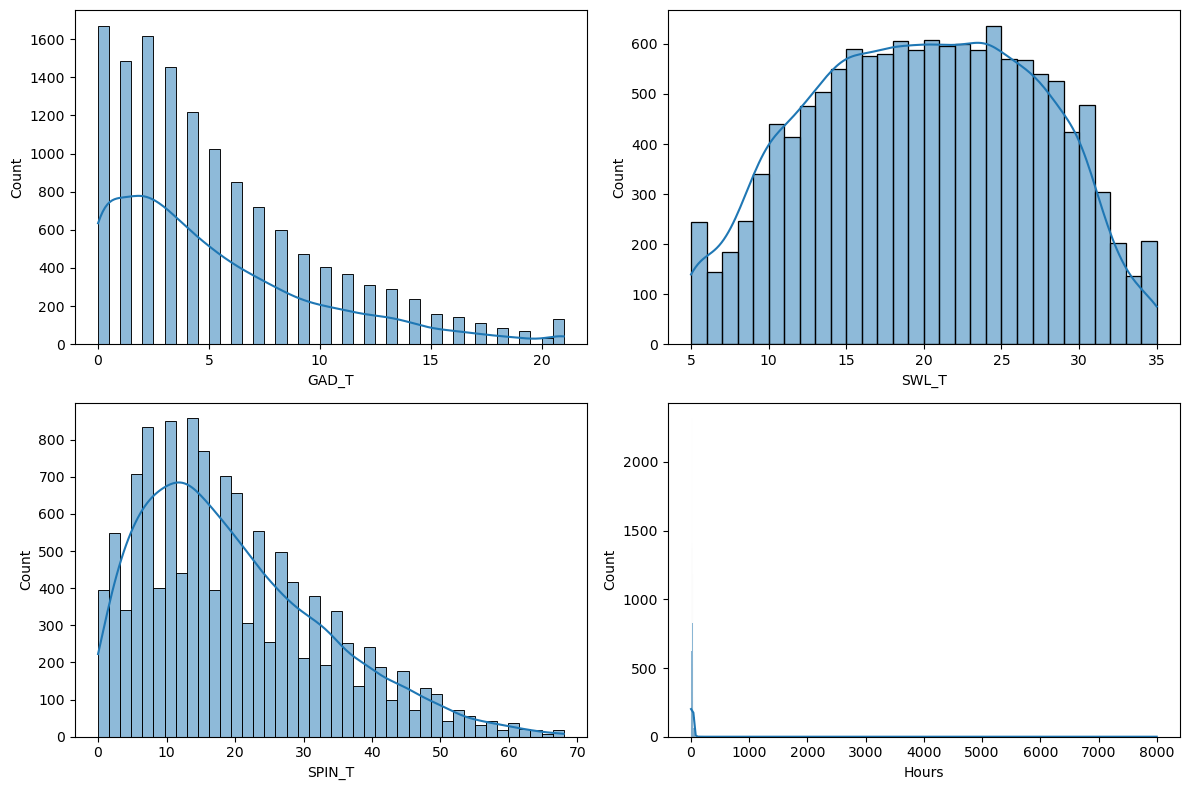

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["GAD_T"], kde=True, ax=ax[0,0])
sns.histplot(df["SWL_T"], kde=True, ax=ax[0,1])
sns.histplot(df["SPIN_T"], kde=True, ax=ax[1,0])
sns.histplot(df["Hours"], kde=True, ax=ax[1,1])

plt.tight_layout()
plt.show()

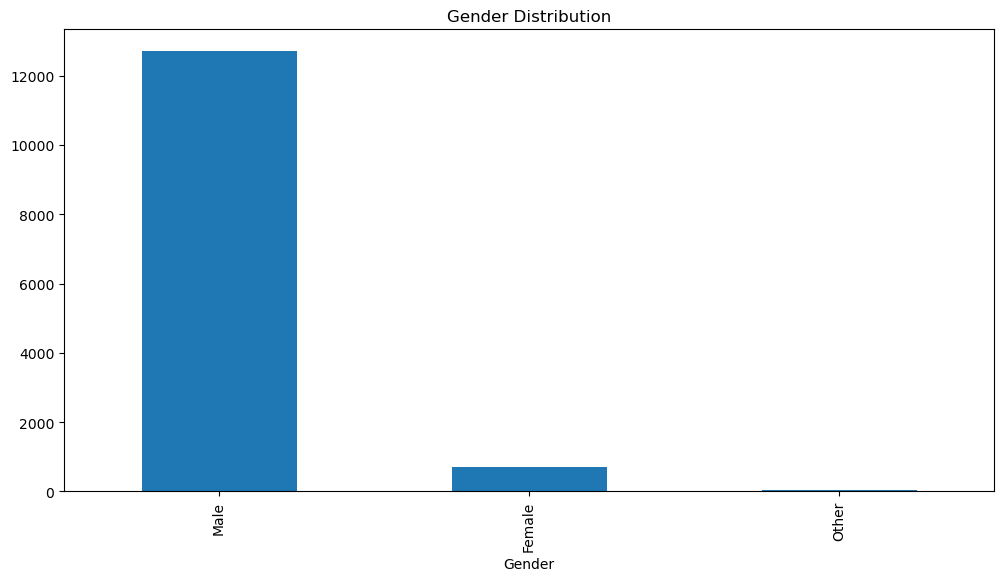

In [7]:
plt.figure(figsize=(12,6))

df["Gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.show()

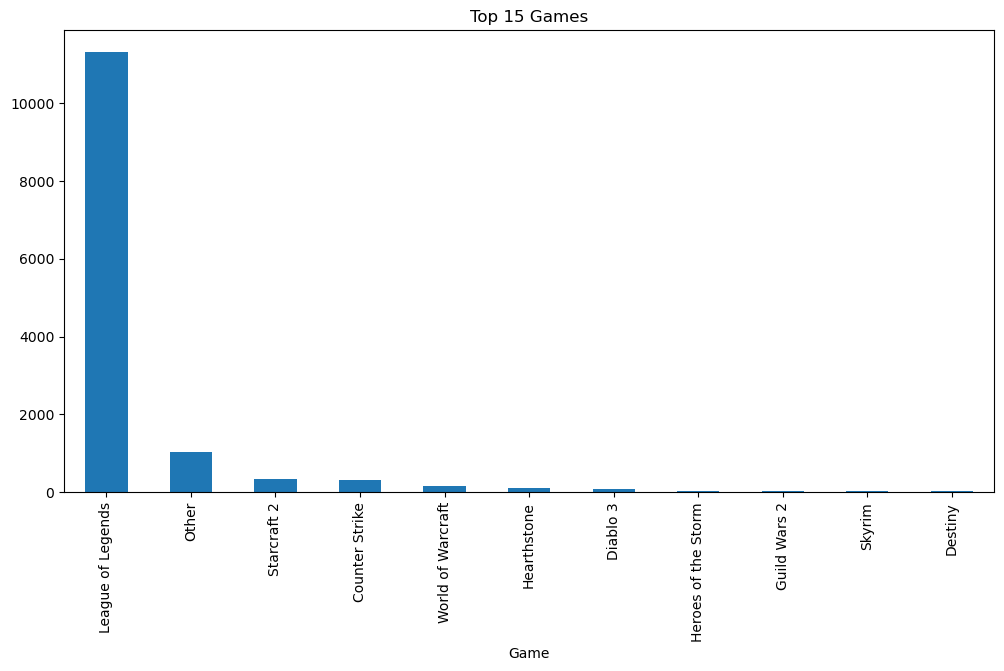

In [8]:
plt.figure(figsize=(12,6))

df["Game"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Games")
plt.show()

In [9]:
# Export by removing outlier for hours

# Remove the extreme outlier observation
df = df[~(
    (df["Hours"] >= 8000) &
    (df["streams"] >= 9000)
)].copy()

# Export cleaned dataset
df.to_csv(
    "/Users/joshpelayo/DATA 5322 02 Statistical Machine Learning 2/Final Project/GamingStudy_data_clean.csv",
    index=False
)

print(df.shape)

(13463, 55)
